<a href="https://colab.research.google.com/github/cramosme/LLM-Phishing-Detection/blob/main/LLM_Phishing_Detection%20V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [278]:
# Clone git repo, comment out after running once
# !git clone https://github.com/cramosme/LLM-Phishing-Detection.git

# %cd LLM-Phishing-Detection

# !ls

In [279]:
import pandas as pd

# Load the CSVs
df_llm_phish = pd.read_csv(f"/content/LLM-Phishing-Detection/data/llm-generated/llm_generated_emails.csv") # Get data from our created LLM
print(f"Loaded {len(df_llm_phish)} LLM Generated phishing emails")
display(df_llm_phish.info())

print("\n")

df_nigerian = pd.read_csv(f"/content/LLM-Phishing-Detection/data/human-generated/Nigerian_Fraud.csv") # Get nazario data
print(f"Loaded {len(df_nigerian)} Nigerian phishing emails")
display(df_nigerian.info())

print("\n")

# Sample 1000 from the dataset
nigerian_sample = df_nigerian.sample(n=1000, random_state=42)

# Combine them
# df_human_phish = pd.concat([nazario_sample, nigerian_sample], ignore_index=True)
df_human_phish = nigerian_sample
print(f"Loaded {len(df_nigerian)} Sample of phishing emails")
display(df_human_phish.info())


Loaded 1000 LLM Generated phishing emails
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    1000 non-null   object
 1   label   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


None



Loaded 3332 Nigerian phishing emails
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3332 entries, 0 to 3331
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sender    3001 non-null   object
 1   receiver  2008 non-null   object
 2   date      2850 non-null   object
 3   subject   3293 non-null   object
 4   body      3332 non-null   object
 5   urls      3332 non-null   int64 
 6   label     3332 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 182.3+ KB


None



Loaded 3332 Sample of phishing emails
<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 438 to 1159
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sender    902 non-null    object
 1   receiver  617 non-null    object
 2   date      850 non-null    object
 3   subject   988 non-null    object
 4   body      1000 non-null   object
 5   urls      1000 non-null   int64 
 6   label     1000 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 62.5+ KB


None

## Printing out the value count to check that all 1000 values are the same. Phish is 1. Legit is 0.

In [280]:
df_llm_phish['label'].value_counts()

,count
label,
1,1000


In [281]:
df_human_phish['label'].value_counts()

,count
label,
1,1000


In [282]:
# Extract only the body text from the Human CSVs for consistency. LLM CSVs only contain a text box, with no metadata like the Human ones.
# If we use the metadata in training the model might spot patterns and classify anything with metadata as Human.
# To avoid that we will only be looking at the body of the email.

# Add text column to human dataframes, just to keep columns consistent with LLM
df_human_phish['text'] = df_human_phish['body']

# Make sure both columns got added
df_human_phish.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 438 to 1159
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sender    902 non-null    object
 1   receiver  617 non-null    object
 2   date      850 non-null    object
 3   subject   988 non-null    object
 4   body      1000 non-null   object
 5   urls      1000 non-null   int64 
 6   label     1000 non-null   int64 
 7   text      1000 non-null   object
dtypes: int64(2), object(6)
memory usage: 70.3+ KB


In [283]:
# Will be conducting two training experiments. Training the ML model on only the phishing emails and training on all emails.
# We want to see if the model's performance is impacted.

# Add source labels to each dataframe
df_human_phish['source'] = 0    # Human
df_llm_phish['source'] = 1      # LLM

# Create combined dataset
df_phishing_only = pd.concat([
    df_llm_phish[['text','source']], df_human_phish[['text','source']]
], ignore_index=True)

# Verify the dataset
print("=== Phishing Combined Dataset ===")
print(f"Total samples: {len(df_phishing_only)}")
print(df_phishing_only['source'].value_counts())


=== Phishing Combined Dataset ===
Total samples: 2000
source
1    1000
0    1000
Name: count, dtype: int64


In [284]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, classification_report, recall_score, precision_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Random State
rState = 42
test_size = 0.2 # 80% train, 20% test

# Using the 3000 most important words. Stop words english removes common words ("the", "and"...)
vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')

In [285]:
# Phishing Only (Human vs LLM Phishing emails)

# Separating features and labels
X_phish = df_phishing_only['text']
y_phish = df_phishing_only['source']

# Converting text to numbers using TFIDF
X_phish_conversion = vectorizer.fit_transform(X_phish)
print(f"Created {X_phish_conversion.shape[1]} features from the text (top {X_phish_conversion.shape[1]} words)")

X_train_phish, X_test_phish, y_train_phish, y_test_phish = train_test_split(X_phish_conversion, y_phish, test_size=test_size, random_state=rState, stratify=y_phish) # Stratify ensures that its even 800/800 split

print(f"\nTraining samples: {X_train_phish.shape[0]}")
print(f"Testing samples: {X_test_phish.shape[0]}")
print(f"\nClass distribution in training:")
print(y_train_phish.value_counts())

Created 3000 features from the text (top 3000 words)

Training samples: 1600
Testing samples: 400

Class distribution in training:
source
1    800
0    800
Name: count, dtype: int64


# Logistic Regression

In [286]:
# Train logistic regression model

# Initialize model
log_reg = LogisticRegression(max_iter=1000, random_state=rState, solver='liblinear')

# Fit the model
log_reg.fit(X_train_phish, y_train_phish)

y_pred_phish = log_reg.predict(X_test_phish)
y_prob_phish = log_reg.predict_proba(X_test_phish)[:, 1] # Probability of LLM (class 1)



Accuracy: 0.9900
Precision: 0.9804
Recall: 1.0000
F1 Score: 0.9901


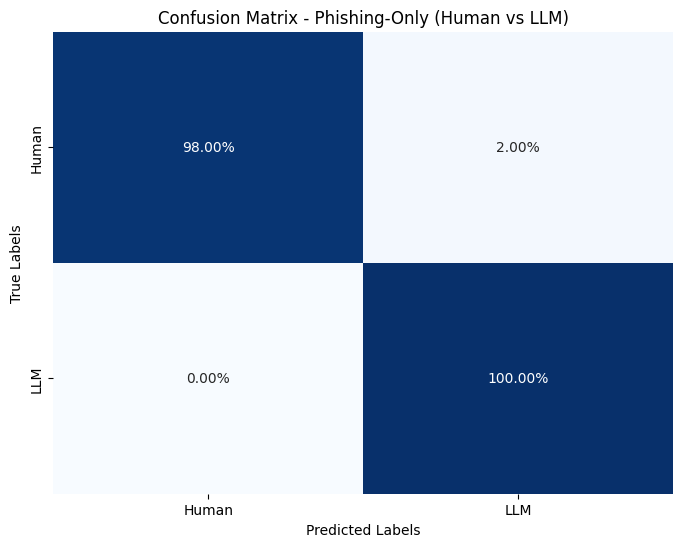


------------------------------------------------------------
               Classification Report
              precision    recall  f1-score   support

       Human       1.00      0.98      0.99       200
         LLM       0.98      1.00      0.99       200

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



In [287]:
# Calculate metrics
accuracy = accuracy_score(y_test_phish, y_pred_phish)
precision = precision_score(y_test_phish, y_pred_phish)
recall = recall_score(y_test_phish, y_pred_phish)
f1 = f1_score(y_test_phish, y_pred_phish)

# Print metrics
print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test_phish, y_pred_phish, normalize="true")
labels = ["Human", "LLM"]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues', cbar=False, xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Phishing-Only (Human vs LLM)')
plt.show()

# Classification Report
print("\n" + "-" * 60)
print(' ' * 15 + "Classification Report")
print(classification_report(y_test_phish, y_pred_phish, target_names=labels))

In [288]:
# Create a dataframe with test results
test_results = pd.DataFrame({
    'text': df_phishing_only.loc[y_test_phish.index, 'text'], # the email text
    'true_label': y_test_phish.values, # What the actual label is
    'predicted_label': y_pred_phish, # What the model predicted
    'probability_LLM': y_prob_phish # How confident the model was
})

# Find misclassified emails, filters to only the rows where true label doesnt match predicted
misclassified = test_results[test_results['true_label'] != test_results['predicted_label']]

print(f"\nTotal misclassified: {len(misclassified)}")

# Show each misclassified email
for index, row in misclassified.iterrows():
    true_class = "LLM" if row['true_label'] == 1 else "Human"
    pred_class = "LLM" if row['predicted_label'] == 1 else "Human"

    print(f"\nMisclassified Email #{index}")
    print(f"True Label: {true_class}")
    print(f"Predicted: {pred_class}")
    print(f"Confidence: {row['probability_LLM']:.4f}")
    print(f"\nEmail Text (first 500 characters):")
    print("-" * 60)
    print(row['text'][:500])


Total misclassified: 4

Misclassified Email #1270
True Label: Human
Predicted: LLM
Confidence: 0.7221

Email Text (first 500 characters):
------------------------------------------------------------
Customer Survey - Get $40 Reward                                                                              > Dear            Chase valued customer ,                 > You have been chosen by the Chase Bank online department to                      take part in our quick and easy 5 question survey. In return                      we will credit $40 to your account . Just for your time! > Helping us better understand how our customers feel benefits                      everyone. With the informa

Misclassified Email #1847
True Label: Human
Predicted: LLM
Confidence: 0.7554

Email Text (first 500 characters):
------------------------------------------------------------
Hi,

VdIAGRA for LESS http://www.oertionpidsadjinde.com

 
struggle going on-apparently they are securing the bound man to 

# Random Forest

In [289]:
# Initialize the random forest
rf = RandomForestClassifier(n_estimators=100, random_state=rState, n_jobs=1)

# Fit the model
rf.fit(X_train_phish, y_train_phish)

# Make pred
rf_y_pred = rf.predict(X_test_phish)
rf_y_prob = rf.predict_proba(X_test_phish)[:, 1]


Accuracy: 0.9975
Precision: 0.9950
Recall: 1.0000
F1 Score: 0.9975


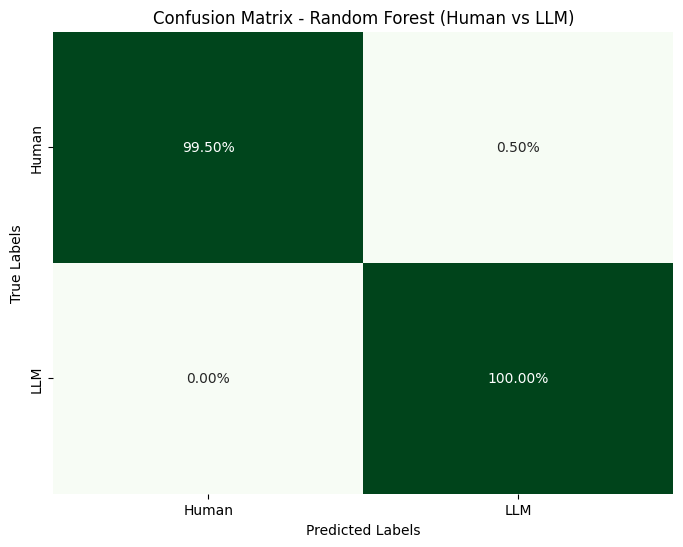


------------------------------------------------------------
               Classification Report
              precision    recall  f1-score   support

       Human       1.00      0.99      1.00       200
         LLM       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [290]:
# Calculate metrics
accuracy_rf = accuracy_score(y_test_phish, rf_y_pred)
precision_rf = precision_score(y_test_phish, rf_y_pred)
recall_rf = recall_score(y_test_phish, rf_y_pred)
f1_rf = f1_score(y_test_phish, rf_y_pred)

# Print metrics
print(f"\nAccuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")

# Confusion Matrix
cm_rf = confusion_matrix(y_test_phish, rf_y_pred, normalize="true")

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='.2%', cmap='Greens', cbar=False, xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Random Forest (Human vs LLM)')
plt.show()

# Classification Report
print("\n" + "-" * 60)
print(' ' * 15 + "Classification Report")
print(classification_report(y_test_phish, rf_y_pred, target_names=labels))

In [291]:
# Create a dataframe with test results
test_results = pd.DataFrame({
    'text': df_phishing_only.loc[y_test_phish.index, 'text'], # the email text
    'true_label': y_test_phish.values, # What the actual label is
    'predicted_label': rf_y_pred, # What the model predicted
    'probability_LLM': rf_y_prob # How confident the model was
})

# Find misclassified emails, filters to only the rows where true label doesnt match predicted
misclassified = test_results[test_results['true_label'] != test_results['predicted_label']]

print(f"\nTotal misclassified: {len(misclassified)}")

# Show each misclassified email
for index, row in misclassified.iterrows():
    true_class = "LLM" if row['true_label'] == 1 else "Human"
    pred_class = "LLM" if row['predicted_label'] == 1 else "Human"

    print(f"\nMisclassified Email #{index}")
    print(f"True Label: {true_class}")
    print(f"Predicted: {pred_class}")
    print(f"Confidence: {row['probability_LLM']:.4f}")
    print(f"\nEmail Text (first 500 characters):")
    print("-" * 60)
    print(row['text'][:500])


Total misclassified: 1

Misclassified Email #1847
True Label: Human
Predicted: LLM
Confidence: 0.5800

Email Text (first 500 characters):
------------------------------------------------------------
Hi,

VdIAGRA for LESS http://www.oertionpidsadjinde.com

 
struggle going on-apparently they are securing the bound man to the
indeed! A complete corruption of history.




In [293]:
# Note:
# Dataset has some obvious words that I think the model is using to classify
# some of the human ones contain an email while none of the LLM ones do, also dates
# A lot of the LLM ones have specific openers and closers
# Just realized some legit LLM emails sound like phishing emails.
# We're cooked
# Probably have to find a dataset with only human generated legit & phishing
# Then generate all the LLM ones using Claude or Chatgpt

# Get features names
feature_names = vectorizer.get_feature_names_out()
feature_coefficients = log_reg.coef_[0]

# pair the 2
feature_importance = pd.DataFrame({
    'word': feature_names,
    'weight': feature_coefficients
})

feature_importance = feature_importance.sort_values('weight', ascending=False)

# Show top 20 LLM indicators
print("Top 20 most used LLM words:")
print(feature_importance.head(20))

# Show top 20 Human indicators
print("\nTop 20 most used Human words:")
print(feature_importance.tail(20)) # lowest # is most used

Top 20 most used LLM words:
              word    weight
630            com  3.628495
2518         shows  1.976945
2837        update  1.267648
2874        verify  1.224159
2381        review  1.096766
138         access  1.090552
1982       package  1.028788
101            847  1.026972
769         credit  0.934146
227          alert  0.915857
838       delivery  0.875655
2270        refund  0.854002
2022       payment  0.809459
1372          hour  0.808825
2014      password  0.755875
2873  verification  0.745522
2363       restore  0.745117
1373         hours  0.727857
1173           fix  0.722904
2309        remote  0.698108

Top 20 most used Human words:
             word    weight
1454  information -1.287373
812          dear -1.301872
2764     transfer -1.322714
1134       father -1.328538
936       dollars -1.332839
319    assistance -1.353042
1572          kin -1.393409
487      business -1.448914
1784      million -1.496664
2905         want -1.543601
712       contact -1.608